In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully")

Libraries imported successfully


In [4]:
df = pd.read_csv("/content/Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [9]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [12]:
df["Survived"].value_counts()

,count
Survived,
0,549
1,342


In [13]:
df["Survived"].value_counts(normalize=True) * 100

,proportion
Survived,
0,61.616162
1,38.383838


In [14]:
df["Sex"].value_counts()

,count
Sex,
male,577
female,314


In [15]:
df["Sex"].value_counts(normalize=True) * 100

,proportion
Sex,
male,64.758698
female,35.241302


In [16]:
df["Pclass"].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [17]:
df["Pclass"].value_counts(normalize=True) * 100

,proportion
Pclass,
3,55.106622
1,24.242424
2,20.650954


In [18]:
df["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [19]:
df["Embarked"].value_counts(normalize=True) * 100

,proportion
Embarked,
S,72.440945
C,18.897638
Q,8.661417


In [20]:
df.nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


# Data Cleaning and Missing Value

In [21]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [22]:
df = df.drop(columns=["Cabin"])
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [23]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [24]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


#Exploratory Data Analysis (EDA)

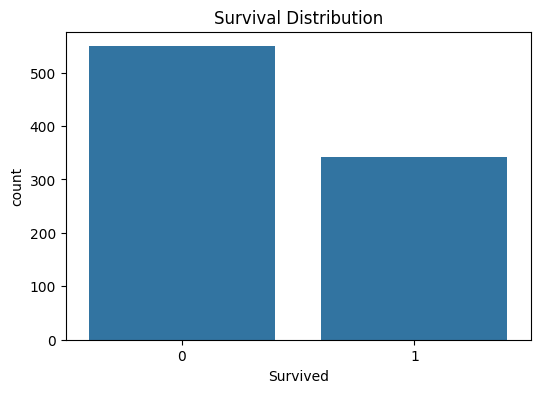

In [25]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Survived")
plt.title("Survival Distribution")
plt.show()

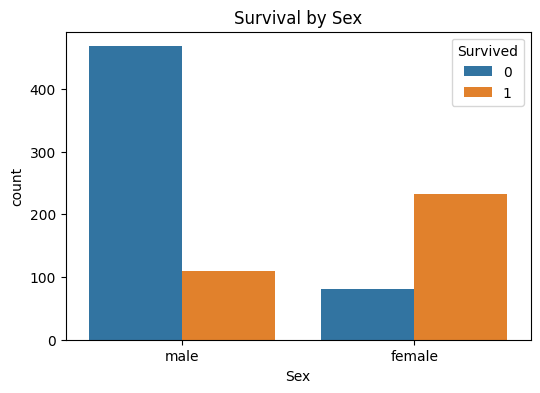

In [26]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Sex")
plt.show()

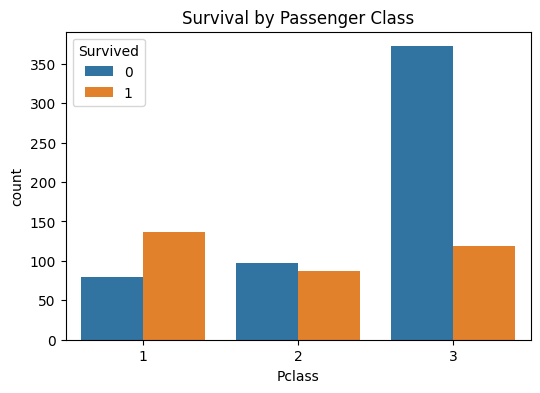

In [27]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.show()

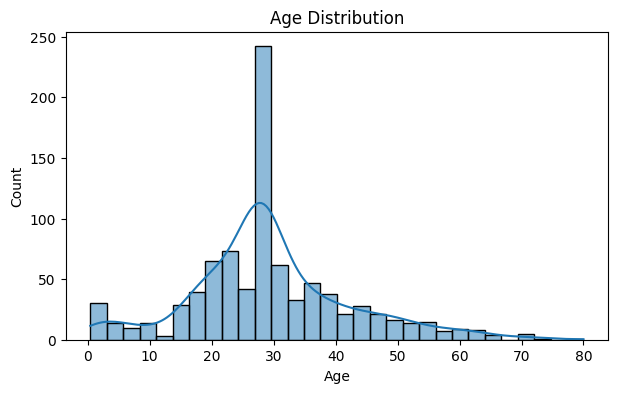

In [28]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="Age", bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

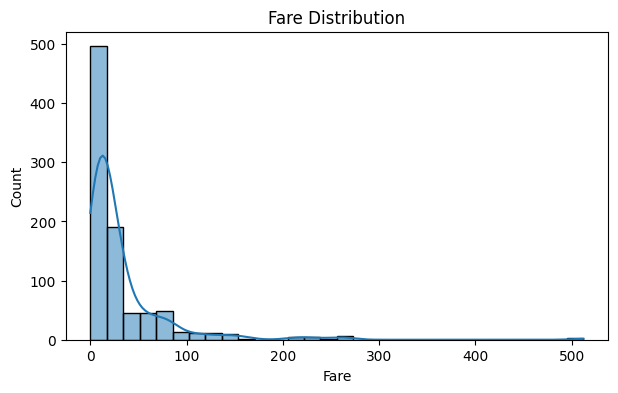

In [29]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="Fare", bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()

#Feature Selection and Train-Test Split

In [30]:
X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]
y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape
X_test.shape

(179, 7)

#Data Preprocessing

In [31]:
numerical_features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]

categorical_features = ["Sex", "Embarked"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

#Classification

In [32]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=42))
    ]
)

logistic_pipeline.fit(X_train, y_train)

y_pred = logistic_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8044692737430168
Precision: 0.7931034482758621
Recall: 0.6666666666666666
F1 Score: 0.7244094488188977
[[98 12]
 [23 46]]
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



#Logistic Regression - Decision Tree

In [33]:
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

decision_tree_pipeline.fit(X_train, y_train)

dt_pred = decision_tree_pipeline.predict(X_test)

print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:", recall_score(y_test, dt_pred))
print("F1 Score:", f1_score(y_test, dt_pred))

print(confusion_matrix(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Decision Tree Results
Accuracy: 0.8268156424581006
Precision: 0.8064516129032258
Recall: 0.7246376811594203
F1 Score: 0.7633587786259542
[[98 12]
 [19 50]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       110
           1       0.81      0.72      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179



#Random Forest Classifier

In [34]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42))
    ]
)

random_forest_pipeline.fit(X_train, y_train)

rf_pred = random_forest_pipeline.predict(X_test)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))

print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Results
Accuracy: 0.8212290502793296
Precision: 0.8135593220338984
Recall: 0.6956521739130435
F1 Score: 0.75
[[99 11]
 [21 48]]
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.70      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



#Model Comparison

In [35]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],

    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],

    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],

    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409
1,Decision Tree,0.826816,0.806452,0.724638,0.763359
2,Random Forest,0.821229,0.813559,0.695652,0.750000


#ROC-AUC

In [36]:
logistic_prob = logistic_pipeline.predict_proba(X_test)[:, 1]
dt_prob = decision_tree_pipeline.predict_proba(X_test)[:, 1]
rf_prob = random_forest_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, logistic_prob))
print("Decision Tree ROC-AUC:", roc_auc_score(y_test, dt_prob))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_prob))

Logistic Regression ROC-AUC: 0.844532279314888
Decision Tree ROC-AUC: 0.8054018445322793
Random Forest ROC-AUC: 0.8272068511198946


#Class Imbalance Handling

In [37]:
balanced_logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            random_state=42
        ))
    ]
)

balanced_logistic_pipeline.fit(X_train, y_train)

balanced_pred = balanced_logistic_pipeline.predict(X_test)

print("Balanced Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, balanced_pred))
print("Precision:", precision_score(y_test, balanced_pred))
print("Recall:", recall_score(y_test, balanced_pred))
print("F1 Score:", f1_score(y_test, balanced_pred))

Balanced Logistic Regression Results
Accuracy: 0.8044692737430168
Precision: 0.7297297297297297
Recall: 0.782608695652174
F1 Score: 0.7552447552447552


#Hyperparameter Tuning

In [38]:
param_grid = {
    "classifier__max_depth": [3, 5, 7, 10],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    decision_tree_pipeline,
    param_grid,
    cv=5,
    scoring="f1"
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Pclass',
                                                                          'Age',
                                                                          'SibSp',
                                                                          'Parch',
                                                                          'Fare']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Sex',
                                                                          'Embarked'])])),
                                       ('classifier',
                                        DecisionTreeClassifier(random_state=42))]),
             param_grid={'classifier__max_depth': [3, 5, 7, 10],
                         'classifier__min_samples_leaf': [1, 2, 4],
                         'classifier__min_samples_split': [2, 5, 10]},
             scoring='f1')

In [39]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

Best Parameters: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10}
Best CV F1 Score: 0.7495467447853319


#Evaluate Tuned Decision Tree

In [40]:
best_model = grid_search.best_estimator_

tuned_pred = best_model.predict(X_test)

print("Tuned Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, tuned_pred))
print("Precision:", precision_score(y_test, tuned_pred))
print("Recall:", recall_score(y_test, tuned_pred))
print("F1 Score:", f1_score(y_test, tuned_pred))

Tuned Decision Tree Results
Accuracy: 0.7932960893854749
Precision: 0.7580645161290323
Recall: 0.6811594202898551
F1 Score: 0.7175572519083969


# Tuning Observation

The tuned Decision Tree didn't improve the test performance, compared with the original Decision Tree. The original model achieved higher accuracy and F1-score on the test set.

#SMOTE - Class Imbalance Handling

In [41]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Survived
0    439
1    273
Name: count, dtype: int64

After SMOTE:
Survived
1    439
0    439
Name: count, dtype: int64


In [42]:
smote_logistic = LogisticRegression(random_state=42)

smote_logistic.fit(X_train_smote, y_train_smote)

smote_pred = smote_logistic.predict(X_test_processed)

print("SMOTE Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, smote_pred))
print("Precision:", precision_score(y_test, smote_pred))
print("Recall:", recall_score(y_test, smote_pred))
print("F1 Score:", f1_score(y_test, smote_pred))


SMOTE Logistic Regression Results
Accuracy: 0.8100558659217877
Precision: 0.7397260273972602
Recall: 0.782608695652174
F1 Score: 0.7605633802816901


In [43]:
imbalance_comparison = pd.DataFrame({
    "Method": [
        "Baseline",
        "Class Weight Balanced",
        "SMOTE"
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, balanced_pred),
        precision_score(y_test, smote_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, balanced_pred),
        recall_score(y_test, smote_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, balanced_pred),
        f1_score(y_test, smote_pred)
    ]
})

imbalance_comparison

,Method,Precision,Recall,F1 Score
0,Baseline,0.793103,0.666667,0.724409
1,Class Weight Balanced,0.729730,0.782609,0.755245
2,SMOTE,0.739726,0.782609,0.760563


# Imbalance Handling Observation

We see both class weighting and SMOTE improved recall from 66.67% to 78.26%. As SMOTE achieved the highest F1-score of 76.06% among the three approaches as showing the strongest balance between precision and recall in comparison. Since the baseline model had higher precision but lower recall.

# Random Forest Hyperparameter Tuning

In [44]:
rf_tuning_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        oob_score=True
    ))
])

rf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__max_features": ["sqrt", "log2"]
}

rf_grid_search = GridSearchCV(
    rf_tuning_pipeline,
    rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid_search.fit(X_train, y_train)

print("Best Parameters:", rf_grid_search.best_params_)
print("Best CV F1 Score:", rf_grid_search.best_score_)

Best Parameters: {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}
Best CV F1 Score: 0.7452284893229187


In [45]:
#OOB score
best_rf_model = rf_grid_search.best_estimator_

oob_score = best_rf_model.named_steps["classifier"].oob_score_

print("OOB Score:", oob_score)

OOB Score: 0.8061797752808989


#Random Forest Tuning Observation

GridSearchCV selected a Random Forest with 100 trees with a maximum depth of 10 and sqrt as the max features setting. The best cross-validation F1-score was approximately 74.52%. Then the tuned model achieved an OOB score of approximately 80.62%, providing an additional estimate of its performance on unseen samples.

# Decision Tree Visualization

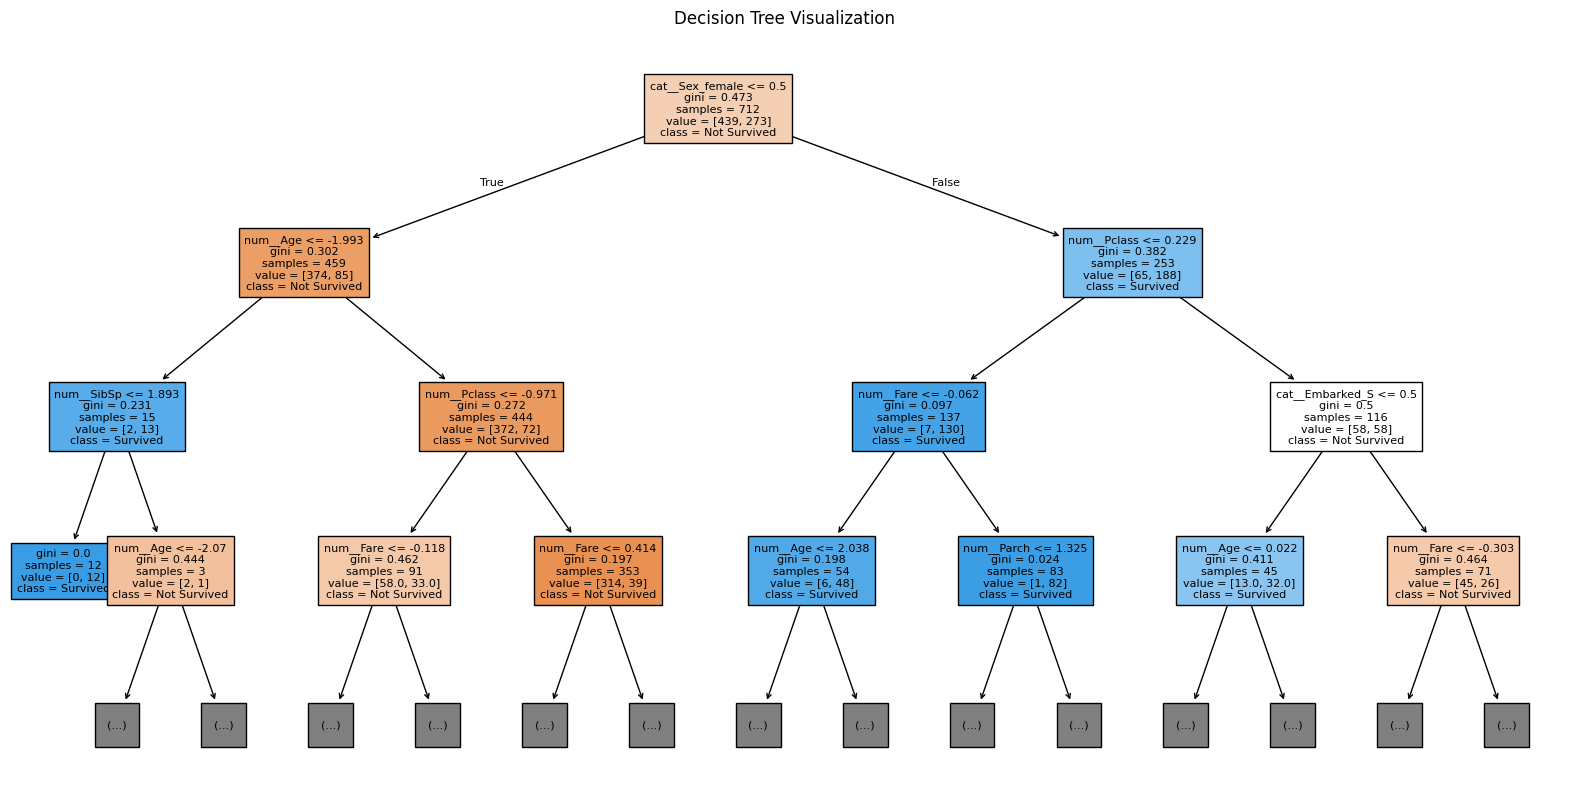

In [46]:
from sklearn.tree import plot_tree

feature_names = decision_tree_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree_pipeline.named_steps["classifier"],
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Visualization")
plt.show()

# ROC Curve Comparison

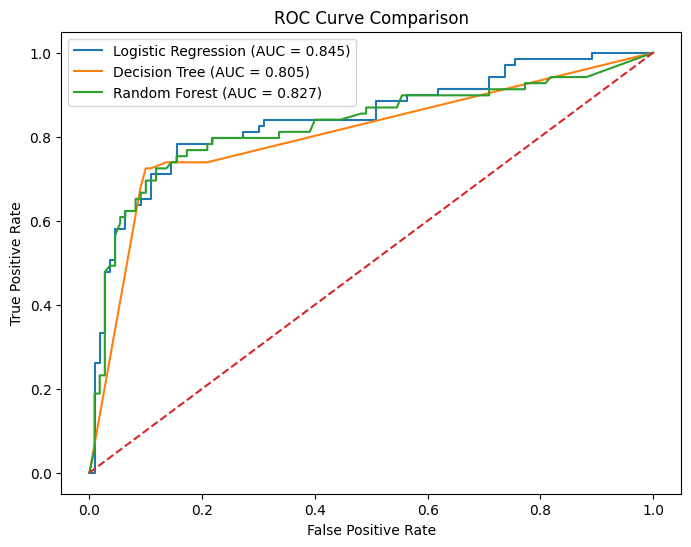

In [47]:
from sklearn.metrics import roc_curve, roc_auc_score

logistic_fpr, logistic_tpr, _ = roc_curve(y_test, logistic_prob)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

logistic_auc = roc_auc_score(y_test, logistic_prob)
dt_auc = roc_auc_score(y_test, dt_prob)
rf_auc = roc_auc_score(y_test, rf_prob)

plt.figure(figsize=(8, 6))

plt.plot(logistic_fpr, logistic_tpr,
         label=f"Logistic Regression (AUC = {logistic_auc:.3f})")

plt.plot(dt_fpr, dt_tpr,
         label=f"Decision Tree (AUC = {dt_auc:.3f})")

plt.plot(rf_fpr, rf_tpr,
         label=f"Random Forest (AUC = {rf_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [48]:
classification_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ],
    "AUC": [
        logistic_auc,
        dt_auc,
        rf_auc
    ]
})

classification_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8445
1,Decision Tree,0.8268,0.8065,0.7246,0.7634,0.8054
2,Random Forest,0.8212,0.8136,0.6957,0.7500,0.8272


# Additional EDA Analysis & Missing Value Percentage

In [49]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage[missing_percentage > 0]

,0


In [50]:
for column in ["Age", "Fare"]:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Number of Outliers:", len(outliers))
    print()

Age
Q1: 22.0
Q3: 35.0
IQR: 13.0
Number of Outliers: 66

Fare
Q1: 7.9104
Q3: 31.0
IQR: 23.0896
Number of Outliers: 116



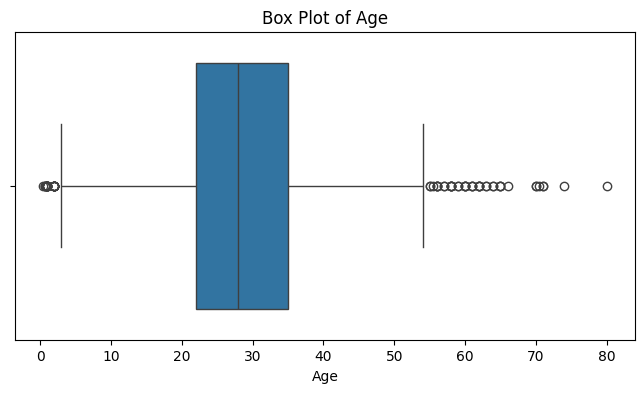

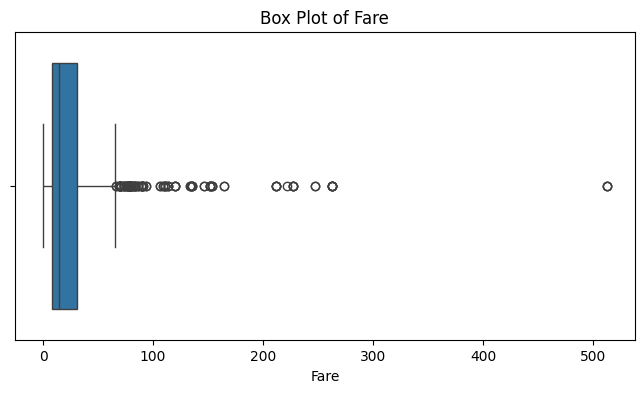

In [51]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["Age"])
plt.title("Box Plot of Age")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=df["Fare"])
plt.title("Box Plot of Fare")
plt.show()

In [52]:
fare_mean = df["Fare"].mean()
fare_median = df["Fare"].median()
fare_mode = df["Fare"].mode()[0]

print("Fare Mean:", fare_mean)
print("Fare Median:", fare_median)
print("Fare Mode:", fare_mode)

Fare Mean: 32.204207968574636
Fare Median: 14.4542
Fare Mode: 8.05


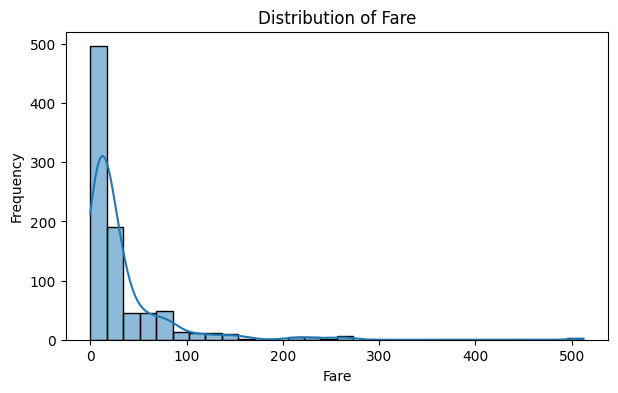

Fare Mean: 32.204207968574636
Fare Median: 14.4542
Fare Mode: 8.05


In [53]:
plt.figure(figsize=(7, 4))

sns.histplot(df["Fare"], bins=30, kde=True)

plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

fare_mean = df["Fare"].mean()
fare_median = df["Fare"].median()
fare_mode = df["Fare"].mode()[0]

print("Fare Mean:", fare_mean)
print("Fare Median:", fare_median)
print("Fare Mode:", fare_mode)

# Fare Distribution Observation

Fare distribution is right skewed because the mean is higher than the median/mode. This indicates that smaller number of passengers paid high fares, pulling the mean upward.

In [54]:
#Survival rate by Sex

survival_by_sex = df.groupby("Sex")["Survived"].mean() * 100
print(survival_by_sex)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


In [55]:
#Survival rate by PClass

survival_by_class = df.groupby("Pclass")["Survived"].mean() * 100
print(survival_by_class)

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


In [56]:
#Survival rate by Sex + PClass

survival_by_sex_class = (
    df.groupby(["Sex", "Pclass"])["Survived"]
    .mean() * 100
)

print(survival_by_sex_class)

Sex     Pclass
female  1         96.808511
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: Survived, dtype: float64


# Correlation Analysis

In [57]:
correlation_columns = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


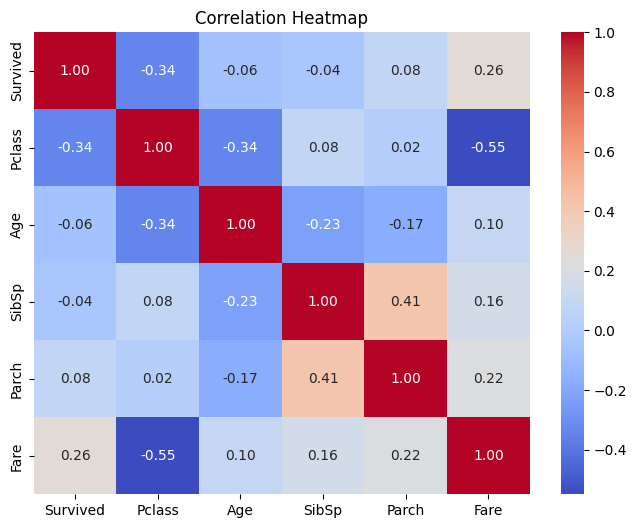

In [58]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# Correlation Observation

The strongest correlation is between Pclass and Fare (-0.55), as it is showing a moderate negative relationship. As this indicates that lower passenger class numbers are generally associated with higher fares.

The second strongest correlation is between SibSp and Parch (0.41), as it is showing a moderate positive relationship. As this suggests that passengers travelling with siblings or spouses are also tended to travel with parents or children.

# Multivariate Analysis

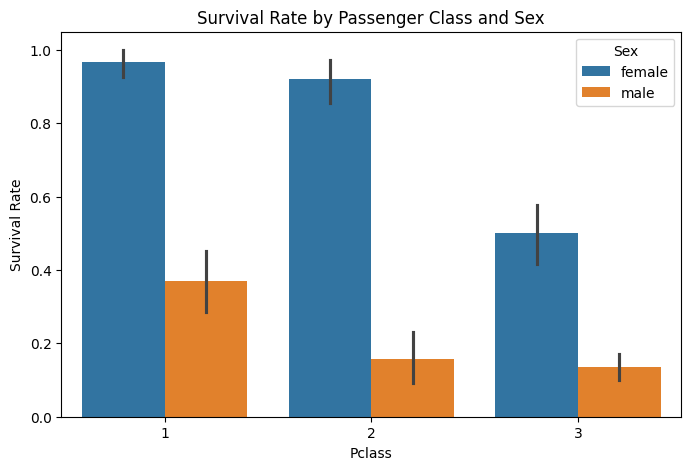

In [59]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Pclass",
    y="Survived",
    hue="Sex"
)

plt.title("Survival Rate by Passenger Class and Sex")
plt.ylabel("Survival Rate")
plt.show()

# Observation

As visible in the chart the Female passengers had higher survival rates than male passengers across all passenger classes. The First class passengers generally had better survival outcomes, while third class passengers especially males, had lower survival rates.

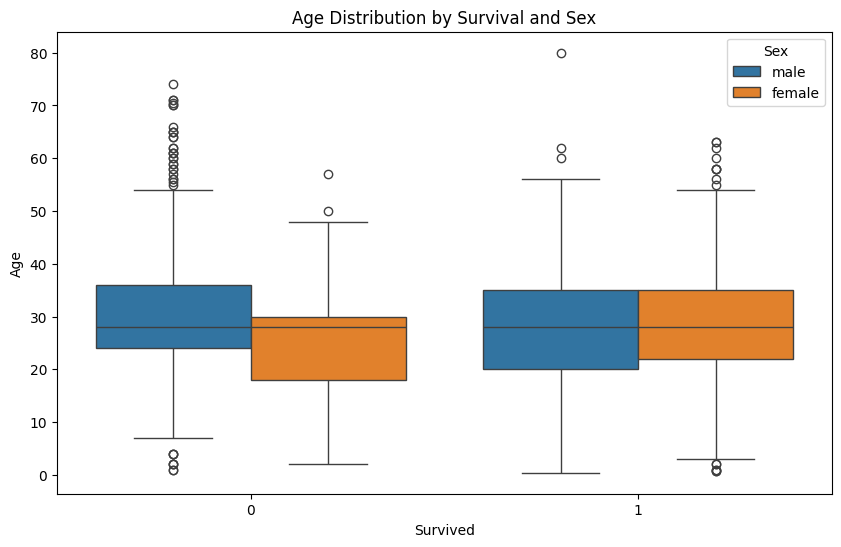

In [60]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Survived",
    y="Age",
    hue="Sex"
)

plt.title("Age Distribution by Survival and Sex")
plt.xlabel("Survived")
plt.ylabel("Age")
plt.show()

# Observation

As visible the median ages of survivors and non survivors are fairly similar for both males and females. Also the age distributions overlap considerably, suggesting that the age alone does not clearly separate survivors from non survivors. Several older age outliers are also visible, especially among male passengers.

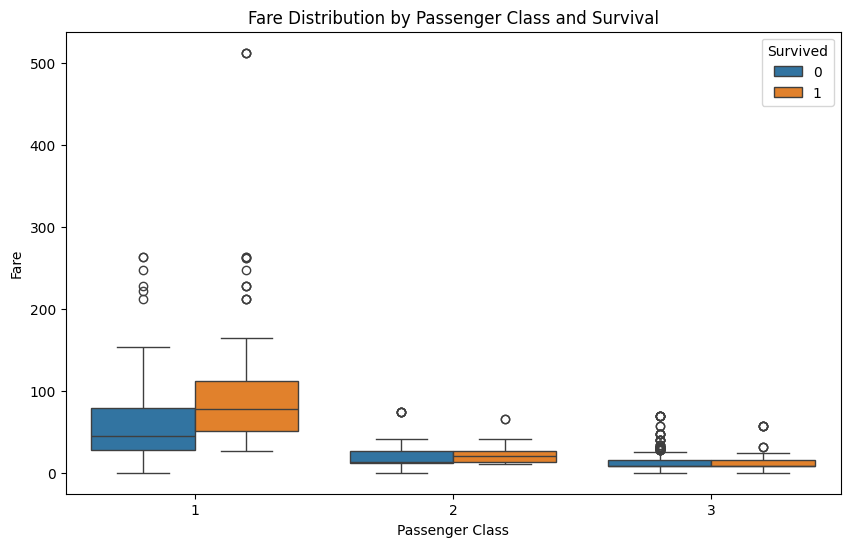

In [61]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Pclass",
    y="Fare",
    hue="Survived"
)

plt.title("Fare Distribution by Passenger Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()

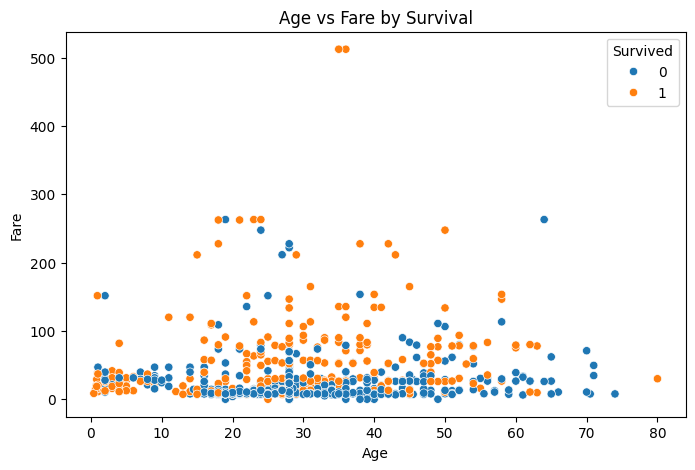

In [62]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Fare",
    hue="Survived"
)

plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()


#Observation

Most of the passengers paid relatively low fares across different age groups. Survivors and non survivors overlap considerably across age and fare, although survivors appear more frequently among some of higher fare passengers. A few very high fare outliers are also visible. Therefore, the age and fare alone do not clearly separate survivors from non survivors.

# Standardization of Age and Fare

In [63]:
scaler_eda = StandardScaler()

scaled_values = scaler_eda.fit_transform(df[["Age", "Fare"]])

scaled_df = pd.DataFrame(
    scaled_values,
    columns=["Age_scaled", "Fare_scaled"]
)

scaled_df.head()

,Age_scaled,Fare_scaled
0,-0.565736,-0.502445
1,0.663861,0.786845
2,-0.258337,-0.488854
3,0.433312,0.420730
4,0.433312,-0.486337


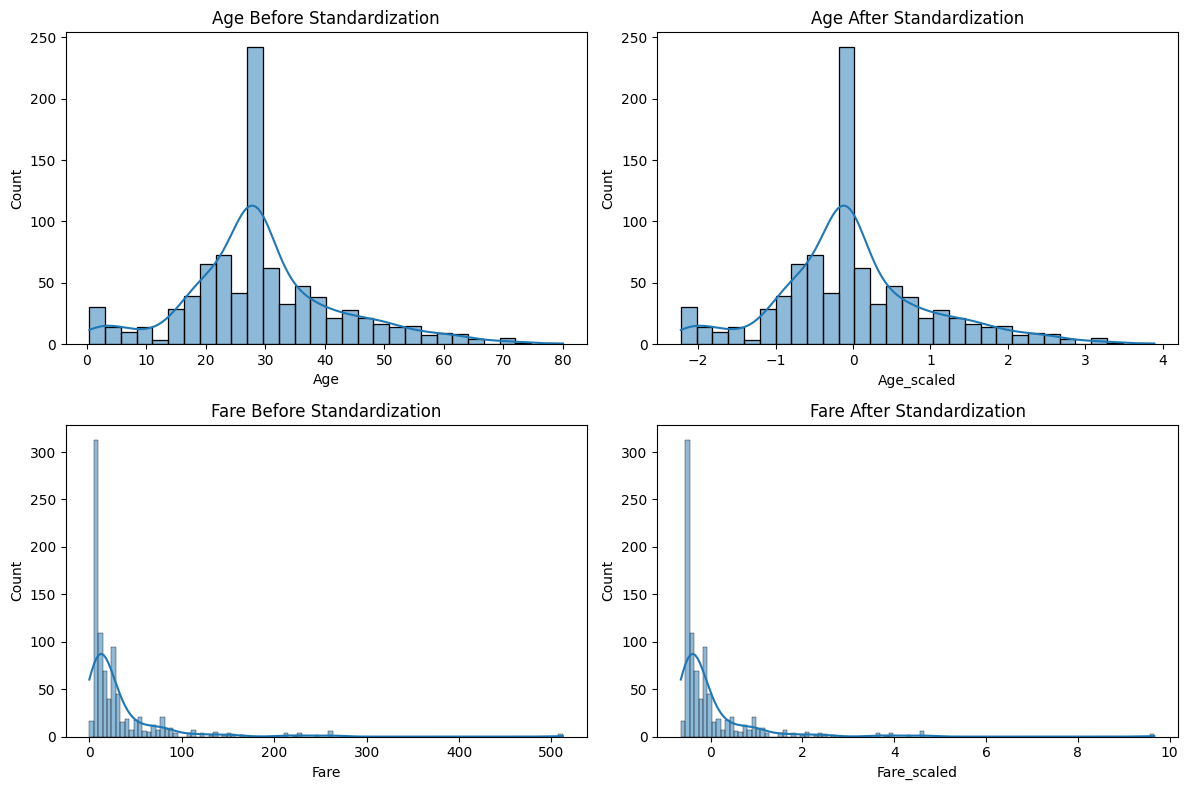

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Age before standardization
sns.histplot(df["Age"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Age Before Standardization")

# Age after standardization
sns.histplot(scaled_df["Age_scaled"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Age After Standardization")

# Fare before standardization
sns.histplot(df["Fare"], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Fare Before Standardization")

# Fare after standardization
sns.histplot(scaled_df["Fare_scaled"], kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Fare After Standardization")

plt.tight_layout()
plt.show()

# Standardization Observation

After standardization, both the age and the fare are transformed to a common scale centered around zero. The overall shapes of their distributions remain similar because standardization changes the scale of values rather than underlying distribution. 'Fare' therefore, remains right skewed even after standardization.

# Regression Analysis - Predicting Fare

A multivariate Linear Regression model is developed to predict passenger Fare using other available passenger features.

In [65]:
reg_X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Embarked"]]

reg_y = df["Fare"]

reg_X.head()

,Pclass,Sex,Age,SibSp,Parch,Embarked
0,3,male,22.0,1,0,S
1,1,female,38.0,1,0,C
2,3,female,26.0,0,0,S
3,1,female,35.0,1,0,S
4,3,male,35.0,0,0,S


In [66]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(reg_X, reg_y, test_size=0.2, random_state=42)

print(X_reg_train.shape)
print(X_reg_test.shape)

(712, 6)
(179, 6)


In [67]:
reg_numerical_features = ["Age", "SibSp", "Parch"]

reg_categorical_features = ["Pclass", "Sex", "Embarked"]

reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), reg_numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), reg_categorical_features)
    ]
)

reg_pipeline = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("regressor", LinearRegression())
])

reg_pipeline.fit(X_reg_train, y_reg_train)

reg_pred = reg_pipeline.predict(X_reg_test)

In [68]:
reg_mae = mean_absolute_error(y_reg_test, reg_pred)
reg_rmse = np.sqrt(mean_squared_error(y_reg_test, reg_pred))
reg_r2 = r2_score(y_reg_test, reg_pred)

n = len(y_reg_test)
p = reg_pipeline.named_steps["preprocessor"].transform(X_reg_test).shape[1]

reg_adjusted_r2 = 1 - ((1 - reg_r2) * (n - 1) / (n - p - 1))

print("MAE:", reg_mae)
print("RMSE:", reg_rmse)
print("R²:", reg_r2)
print("Adjusted R²:", reg_adjusted_r2)

MAE: 18.87024130799582
RMSE: 30.920168541212238
R²: 0.38216458402264963
Adjusted R²: 0.34146883806006967


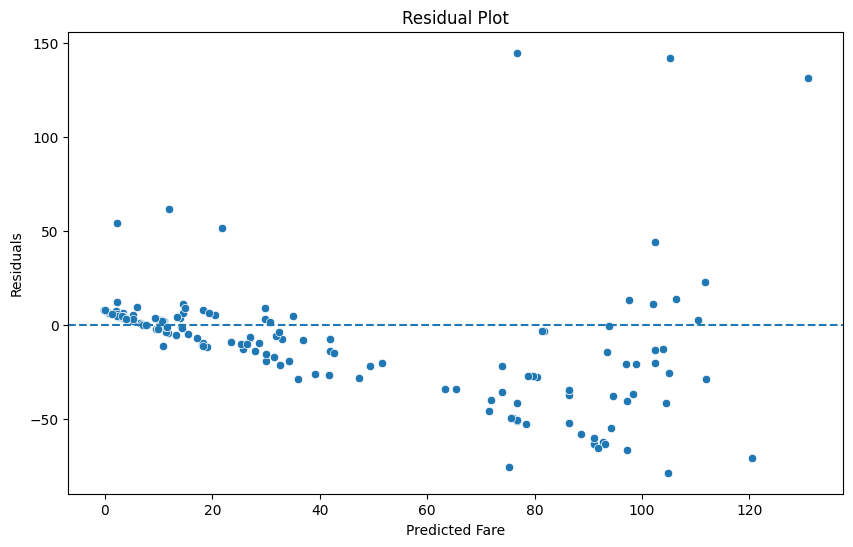

In [69]:
residuals = y_reg_test - reg_pred

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=reg_pred,
    y=residuals
)

plt.axhline(y=0, linestyle="--")

plt.title("Residual Plot")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.show()

#Regression Model Evaluation

The Linear Regression model achieved an MAE of approximately 18.87 and an RMSE of approximately 30.92. The R² score of 0.382 indicates that the model explains about 38.2% of the variation in passenger Fare. The Adjusted R² is approximately 0.341, which accounts for the number of predictors used in the model. The higher RMSE compared with MAE suggests that some larger prediction errors are present.

# Residual Plot Interpretation

The residual plot shows that the spread of residuals increases as predicted Fare becomes higher. At lower predicted Fare values, the residuals are relatively concentrated around zero, while at higher predicted values the residuals show much wider spread with large errors. This fluctuating variance indicates the presence of heteroscedasticity, suggesting that the Linear Regression model does not predict Fare equally well over all fare ranges.

# Final Model Comparison

In [70]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        0.8045,
        0.8268,
        0.8212
    ],
    "Precision": [
        0.7931,
        0.8065,
        0.8136
    ],
    "Recall": [
        0.6667,
        0.7246,
        0.6957
    ],
    "F1 Score": [
        0.7244,
        0.7634,
        0.7500
    ],
    "AUC": [
        0.8445,
        0.8054,
        0.8272
    ]
})

classification_results

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8445
1,Decision Tree,0.8268,0.8065,0.7246,0.7634,0.8054
2,Random Forest,0.8212,0.8136,0.6957,0.7500,0.8272


In [71]:
regression_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [reg_mae],
    "RMSE": [reg_rmse],
    "R²": [reg_r2],
    "Adjusted R²": [reg_adjusted_r2]
})

regression_results

,Model,MAE,RMSE,R²,Adjusted R²
0,Linear Regression,18.870241,30.920169,0.382165,0.341469


# Final Model Recommendation

Among the classification models, the Decision Tree achieved the highest accuracy of 82.68% and F1-score with 76.34%, while Random Forest achieved the highest precision of 81.36%. Logistic Regression achieved the highest AUC with 84.45%, indicating strong overall class discrimination. Considering the balance between accuracy, recall and F1-score in the current test results, the Decision Tree provides strong classification result for this analysis.

The Linear Regression model addresses separate regression task of predicting Fare, so its MAE, RMSE, R² and Adjusted R² metrics are not directly comparable with the classification metrics.

In [72]:
joblib.dump(
    decision_tree_pipeline,
    "best_titanic_pipeline.joblib"
)

print("Pipeline saved successfully")

loaded_pipeline = joblib.load(
    "best_titanic_pipeline.joblib"
)

sample_raw_data = X_test.iloc[[0]]

prediction = loaded_pipeline.predict(sample_raw_data)

print("Raw input:")
display(sample_raw_data)

print("Prediction:", prediction)

Pipeline saved successfully
Raw input:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
565,3,male,24.0,2,0,24.15,S


Prediction: [0]
